# **RELATÓRIO - LH NAUTICAL ⚓**

## **1 - EDA**

In [14]:
# IMPORTANDO BIBLIOTECAS
import pandas as pd 
import os
from datetime import datetime

# CARREGANDO O DATASET
BASE_DIR = os.getcwd()
PATH_VENDAS = os.path.join(BASE_DIR, '..', 'data', 'raw')
df = pd.read_csv(os.path.join(PATH_VENDAS, 'vendas_2023_2024.csv'))

#### **1.1 - Visão geral do dataset (quantidade de linhas, colunas e intervalo de datas):**

In [15]:
#LINHAS E COLUNAS
print(f"Linhas: {df.shape[0]}\nColunas: {df.shape[1]}")

# CONFERINDO AS DATAS
df_data = df.copy()
df_data['sale_date'] = pd.to_datetime(df['sale_date'], format='mixed', dayfirst=True)
print(f"Data mínima: {df_data['sale_date'].min().strftime('%d-%m-%y')} e Data máxima: {df_data['sale_date'].max().strftime('%d-%m-%y')}")

Linhas: 9895
Colunas: 6
Data mínima: 01-01-23 e Data máxima: 31-12-24


#### **1.2 - Análise de valores numéricos da coluna "total":**

In [20]:
#ANÁLISE DA COLUNA TOTAL
print(f"Valor mínimo: {df['total'].min()}")
print(f"Valor máximo: {df['total'].max()}")
print(f"Valor médio: {round(df['total'].mean(), 2)}")
print(f"Mediana: {df['total'].median()}")

#AVALIANDO OUTLIERS PELO MÉTODO INTERQUARTIL
q1 = df['total'].quantile(0.25) 
q3 = df['total'].quantile(0.75)
iqr = q3 - q1
lim_inferior = q1 - 1.5 * iqr
lim_superior = q3 + 1.5 * iqr

outliers_inferiores = df[df['total'] < lim_inferior]
outliers_superiores = df[df['total'] > lim_superior]

print(f"Q1: {q1}\nQ3: {q3}")
print(f"limite inferior: {lim_inferior}\nlimite superior: {lim_superior}")
print(f"outliers inferiores: {outliers_inferiores.shape[0]}")
print(f"outliers superiores: {outliers_superiores.shape[0]}")

# RANKING DE OUTLIERS
outliers_ranking = outliers_superiores.sort_values(by='total', ascending=False)
top_outliers = outliers_ranking[['id_product', 'total']].head(10)
print("Top 10 maiores outliers de vendas:")
print(top_outliers)

Valor mínimo: 294.5
Valor máximo: 2222973.0
Valor médio: 263797.83
Mediana: 82225.0
Q1: 23138.2
Q3: 339094.5
limite inferior: -450796.24999999994
limite superior: 813028.95
outliers inferiores: 0
outliers superiores: 1018
Top 10 maiores outliers de vendas:
      id_product       total
8905          76  2222973.00
3873          76  2222973.00
9623          76  2222973.00
1578          76  2222973.00
7930          73  2147399.00
8856          76  2111824.35
1974          76  2111824.35
8800          76  2074775.00
5014          76  2074775.00
5183          97  2030026.00


Os outliers significativos são os superiores com 1018 casos (cerca de 10% dos dados), que indicam valores  elevados acima dos 2 milhões, principalmente quandoo comparados às medidas de tendencia central deste dataframe. A média de 263 mil e a mediana 82 mil evidenciam a influência dos extremos de cima.

Além disso, só de observar o ranking dos 10 maiores outliers, percebemos mesmo produto (ID 76) aparecendo multiplas vezes entre os maiores, sendo que em quatro delas com o mesmo valor máximo de 2222973, o que pode nos indicar alguma anomalia, como talvez, registros duplicados.


In [22]:
#ANALISANDO OUTLIERS SUSPEITOS
outliers_suspeitos = df[(df['id_product'] == 76) & (df['total'] > 222900)]
print(outliers_suspeitos.head())

      id  id_client  id_product  qtd       total   sale_date
175  179         41          76   14  1971036.25  2024-09-27
598  608         23          76    4   592793.00  29-11-2023
671  681         32          76    3   422365.25  2024-10-06
737  747         11          76   12  1778379.00  2024-02-13
763  773         36          76   10  1407882.90  04-04-2024


Apesar da possibilidade de comportamento anômalo, com o mesmo produto registrando o mesmo total elevado quatro vezes, podemos visualizar que não se trata de duplicatas:

São apenas compras do mesmo produto em mesma quantidade, realizadas por clientes diferentes em datas distintas.

#### **1.3 - Interpretação e diagnóstico para análises futuras:**

In [23]:
#ANALISANDO VALORES NULOS, NEGATIVOS E DUPLICADOS
valores_nulos = df.isnull().sum()
print(f"Valores nulos:\n{valores_nulos}")
valores_negativos = (df.select_dtypes(include='number') < 0).sum()
print(f"Valores negativos:\n{valores_negativos}")
valores_duplicados = df.duplicated().sum()
print(f"Valores duplicados:\n {valores_duplicados}")

Valores nulos:
id            0
id_client     0
id_product    0
qtd           0
total         0
sale_date     0
dtype: int64
Valores negativos:
id            0
id_client     0
id_product    0
qtd           0
total         0
dtype: int64
Valores duplicados:
 0


In [24]:
#ANALISANDO FORMATOS DA COLUNA sale_date
df['sale_date'].astype(str).str.replace(r'\d', 'X', regex=True).value_counts()

sale_date
XX-XX-XXXX    4982
XXXX-XX-XX    4913
Name: count, dtype: int64

##### **Conclusão:**
**Os dados são de qualidade, não constando valores nulos, negativos ou duplicados. Entretanto, temos inconsistências no formato padrão de datas da coluna "sale_date", que apresenta dois tipos de configuração.**

**Ademais, podemos considerar o dataset parcialmente apto para prosseguir nas análises, e que estará completamente pronto após solucionadas inconsistências.**

## **2 - PRODUTOS**


In [30]:
#IMPORTANDO BIBLIOTECA
import pandas as pd
import os

# CARREGANDO O DATASET
BASE_DIR = os.getcwd()
PATH_PRODUTOS = os.path.join(BASE_DIR, '..', 'data', 'raw')
PATH_PROCESSED = os.path.join(BASE_DIR, '..', 'data', 'processed')
df = pd.read_csv(os.path.join(PATH_PRODUTOS, 'produtos_raw.csv'))

#### **2.1 - Padronização dos nomes das categorias de produtos (eletrônicos, propulsão e ancoragem):**

In [27]:
# APONTANDO AS CATEGORIAS ÚNICAS 
print(df['actual_category'].unique())

# FUNCÃO PARA NORMALIZAR AS CATEGORIAS DE PRODUTOS
def normalizar_categoria(categoria):
    '''Normaliza a categoria de produtos: retira os espaços, converte para minúsculas e categoriza com base em radicais em comum'''
    categoria = categoria.strip().lower().replace(' ', '')
    if 'el' in categoria:
        return 'eletrônicos'
    elif 'pr' in categoria:
        return 'propulsão'
    elif 'anc' in categoria or 'cor' in categoria:
        return 'ancoragem'
    return categoria

# APLICANDO A FUNÇÃO DE NORMALIZAÇÃO NA COLUNA 'actual_category'
df['actual_category'] = df['actual_category'].apply(normalizar_categoria)

# CONFERINDO RESULTADOS DA NORMALIZAÇÃO
print(f"{df['actual_category'].value_counts()}\n Total de registros: {df['actual_category'].value_counts().sum()}")

<StringArray>
['eletrônicos', 'propulsão', 'ancoragem']
Length: 3, dtype: str
actual_category
propulsão      53
ancoragem      53
eletrônicos    51
Name: count, dtype: int64
 Total de registros: 157


#### **2.2 - Conversão de valores para o tipo numérico:**

In [28]:
# ANTES DE CONVERTER, NECESSÁRIO RETIRAR CARACTERES DE CIFRÃO
df['price'] = df['price'].astype(str).str.replace('R$', '').str.strip()
df['price'] = pd.to_numeric(df['price'], errors='coerce')

#CONFERINDO RESULTADOS DA CONVERSÃO
print(f"Tipo da coluna price: {df['price'].dtype}")
print(f"Qtd dos valores convertidos: {df['price'].value_counts().sum()}")

Tipo da coluna price: float64
Qtd dos valores convertidos: 157


#### **2.3 - Remoção de duplicados:**

In [29]:
#REMOVENDO REGISTROS DUPLICADOS
antes_remocao = len(df)
df = df.drop_duplicates()
depois_remocao = len(df)
print(f"Registros removidos: {antes_remocao - depois_remocao}")
print(f"Dataset com {depois_remocao} linhas normalizadas e sem duplicatas.")


Registros removidos: 7
Dataset com 150 linhas normalizadas e sem duplicatas.


In [31]:
#SALVANDO O DATASET NORMALIZADO
df.to_csv(os.path.join(PATH_PROCESSED, 'produtos_normalizados.csv'), index=False)

## **3 - CUSTOS DE IMPORTAÇÃO**

In [32]:
#IMPORTANDO BIBLIOTECAS
import pandas as pd
import json
import os

#### **3.1 - Carregar o JSON e gerar novo arquivo CSV:**

In [35]:
#CARREGANDO JSON
BASE_DIR = os.getcwd()
PATH_RAW = os.path.join(BASE_DIR, '..', 'data', 'raw')
PATH_PROCESSED = os.path.join(BASE_DIR, '..', 'data', 'processed')

with open(os.path.join(PATH_RAW, 'custos_importacao.json'), 'r', encoding='utf-8') as arquivo_json:
    dados = json.load(arquivo_json)

# DESANINHANDO JSON PARA CRIAR O DATAFRAME
df_custos_importacao = pd.json_normalize(dados,
                                         record_path=['historic_data'],
                                         meta=['product_id', 'product_name', 'category'])

df_custos_importacao = df_custos_importacao[[
    'product_id', 'product_name', 'category', 'start_date', 'usd_price']]

# EXIBINDO AS PRIMEIRAS LINHAS, AS ÚLTIMAS LINHAS E O FORMATO DO DATAFRAME
display(df_custos_importacao.head(2))
display(df_custos_importacao.tail(2))
print(df_custos_importacao.shape)

#AVALIANDO OS TIPOS DE DADOS
print(f"Tipos de dados:\n{df_custos_importacao.dtypes}")

,product_id,product_name,category,start_date,usd_price
0,1,Transponder AIS Maré Magnum,eletrônicos,10/08/2016,10583.63
1,1,Transponder AIS Maré Magnum,eletrônicos,15/06/2018,8778.36


,product_id,product_name,category,start_date,usd_price
1258,150,Cabo de Nylon Danforth Magnum Vox,ancoragem,04/10/2024,300.96
1259,150,Cabo de Nylon Danforth Magnum Vox,ancoragem,25/10/2024,288.90


(1260, 5)
Tipos de dados:
product_id       object
product_name        str
category            str
start_date          str
usd_price       float64
dtype: object


In [34]:
# CONVERTENDO TIPOS DE DADOS
df_custos_importacao['product_id'] = df_custos_importacao['product_id'].astype(
    int)  

df_custos_importacao['start_date'] = pd.to_datetime(df_custos_importacao['start_date'], 
                                                    errors='coerce', 
                                                    dayfirst=True)

df_custos_importacao['usd_price'] = pd.to_numeric(df_custos_importacao['usd_price'], 
                                                  errors='coerce')

print(f"\nTipos de dados convertidos:\n{df_custos_importacao.dtypes}")
display(df_custos_importacao.head(3))
print(f"Qtd de entradas atualizadas pós normalização: {df_custos_importacao.shape[0]}")




Tipos de dados convertidos:
product_id               int64
product_name               str
category                   str
start_date      datetime64[us]
usd_price              float64
dtype: object


,product_id,product_name,category,start_date,usd_price
0,1,Transponder AIS Maré Magnum,eletrônicos,2016-08-10,10583.63
1,1,Transponder AIS Maré Magnum,eletrônicos,2018-06-15,8778.36
2,1,Transponder AIS Maré Magnum,eletrônicos,2018-09-25,8023.87


Qtd de entradas atualizadas pós normalização: 1260


In [36]:
# SALVANDO EM CSV
df_custos_importacao.to_csv(os.path.join(PATH_PROCESSED, 'custos_importacao.csv'), index=False)

## **4 - DADOS PÚBLICOS**

In [39]:
#IMPORTANDO BIBLIOTECAS
import pandas as pd
import os
import requests
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from matplotlib.ticker import FuncFormatter

# CONFIGURANDO PATHS
BASE_DIR = os.getcwd()
PATH_RAW = os.path.join(BASE_DIR, '..', 'data', 'raw')
PATH_PROCESSED = os.path.join(BASE_DIR, '..', 'data', 'processed')
PATH_PLOTS = os.path.join(BASE_DIR, '..', 'notebook', 'plots')


#### **4.1 - Cálculo e modelagem:**

In [41]:
# --------- PARTE 1: EXTRAINDO COTAÇÕES DO DÓLAR ---------

#API do BACEN para obter as cotações do dólar entre 30 de dezembro de 2022 e 31 dezembro de 2024
url = "https://olinda.bcb.gov.br/olinda/servico/PTAX/versao/v1/odata/CotacaoDolarPeriodo(dataInicial=@dataInicial,dataFinalCotacao=@dataFinalCotacao)?@dataInicial='12-30-2022'&@dataFinalCotacao='12-31-2024'&$format=json" 

# REQUISITANDO API E CONVERTENDO EM DATAFRAME
response = requests.get(url)
data = response.json()
df_cambio = pd.DataFrame(data['value'])

# CONVERTENDO A COLUNA DE DATA PARA O FORMATO CORRETO E EXTRAINDO APENAS A DATA
df_cambio['dataHoraCotacao'] = pd.to_datetime(df_cambio['dataHoraCotacao'])
df_cambio['data'] = df_cambio['dataHoraCotacao'].dt.date

#RENOMEANDO AS COLUNAS PARA FICAR MAIS CLARO
df_cambio = df_cambio.rename(columns={'cotacaoVenda': 'cotacao_vendas'})
df_cambio = df_cambio.rename(columns={'data': 'cotacao_data'})

# MÉDIA DIÁRIA DA COTAÇÃO DE VENDA DO DÓLAR
df_cambio = df_cambio.groupby('cotacao_data')['cotacao_vendas'].mean().reset_index()
print(df_cambio.head(10))

# SALVANDO O DATAFRAME DE COTAÇÃO EM CSV
df_cambio.to_csv(os.path.join(PATH_PROCESSED, 'cambio.csv'), index=False)


  cotacao_data  cotacao_vendas
0   2022-12-30          5.2177
1   2023-01-02          5.3436
2   2023-01-03          5.3759
3   2023-01-04          5.4459
4   2023-01-05          5.4026
5   2023-01-06          5.2855
6   2023-01-09          5.2967
7   2023-01-10          5.2395
8   2023-01-11          5.2020
9   2023-01-12          5.1400


In [47]:
# --------- PARTE 2: EXTRAINDO COTAÇÕES DO DÓLAR ---------

# CARREGANDO OS DADOS DE VENDAS, CUSTOS DE IMPORTAÇÃO E COTAÇÃO DO DÓLAR
df_vendas = pd.read_csv(os.path.join(PATH_RAW, 'vendas_2023_2024.csv'))             
df_custos = pd.read_csv(os.path.join(PATH_PROCESSED, 'custos_importacao.csv'))
df_cambio = pd.read_csv(os.path.join(PATH_PROCESSED, 'cambio.csv')) 

# PADRONIZANDO O FORMATO DAS DATAS
df_vendas['sale_date'] = pd.to_datetime(df_vendas['sale_date'],format='mixed',dayfirst=True)
df_custos['start_date'] = pd.to_datetime(df_custos['start_date'],format='mixed',dayfirst=True)
df_cambio['cotacao_data'] = pd.to_datetime(df_cambio['cotacao_data'],format='mixed',dayfirst=True)

# ORDENANDO OS DATAFRAMES PELAS DATAS
df_vendas = df_vendas.sort_values('sale_date')
df_custos = df_custos.sort_values('start_date')
df_cambio = df_cambio.sort_values('cotacao_data')

# PADRONIZANDO O NOME DA COLUNA DE ID DO PRODUTO 
df_custos = df_custos.rename(columns={'product_id': 'id_product'})

# ASSOCIANDO A COTAÇÃO DE CÂMBIO MAIS PRÓXIMA 
df_vendas_cambio = pd.merge_asof(df_vendas.sort_values('sale_date'), df_cambio.sort_values('cotacao_data'), 
    left_on='sale_date', 
    right_on='cotacao_data', 
    direction='backward')

# ASSOCIANDO O CUSTO MAIS PRÓXIMO (ANTERIOR OU IGUAL) A DATA DE VENDA, CONSIDERANDO O ID DO PRODUTO
df_vendas_cambio_custos = pd.merge_asof(df_vendas_cambio.sort_values('sale_date'), df_custos.sort_values('start_date'), 
    left_on='sale_date', 
    right_on='start_date', 
    by='id_product', 
    direction='backward')

#SALVANDO O DATAFRAME FINAL COM AS INFORMAÇÕES DE VENDAS, COTAÇÃO E CUSTOS
df_vendas_cambio_custos.to_csv(os.path.join(PATH_PROCESSED, 'vendas_cambio_custos.csv'), index=False)

# CALCULO DO CUSTO TOTAL EM REAIS POR TRANSAÇÃO
df_vendas_cambio_custos['custo_reais'] = (df_vendas_cambio_custos['usd_price'] * df_vendas_cambio_custos['cotacao_vendas']) * df_vendas_cambio_custos['qtd']

# IDENTIFICANDO AS TRANSAÇÕES COM PREJUÍZO
df_vendas_cambio_custos['prejuizo'] = df_vendas_cambio_custos['total'] < df_vendas_cambio_custos['custo_reais']
print(df_vendas_cambio_custos['prejuizo'].value_counts())

# CALCULANDO O VALOR DO PREJUÍZO PARA AS TRANSAÇÕES QUE TIVERAM PREJUÍZO, CASO CONTRÁRIO CONSIDERA 0
df_vendas_cambio_custos['valor_prejuizo'] = np.where(df_vendas_cambio_custos['total'] < df_vendas_cambio_custos['custo_reais'],
    df_vendas_cambio_custos['custo_reais'] - df_vendas_cambio_custos['total'], 0)
print(df_vendas_cambio_custos[['id_product', 'sale_date', 'total', 'cotacao_vendas', 'usd_price', 'custo_reais', 'prejuizo', 'valor_prejuizo']].head(10))

# AGREGANDO OS DADOS POR ID DO PRODUTO E NOME DO PRODUTO PARA CALCULAR A RECEITA TOTAL, PREJUÍZO TOTAL E PERCENTUAL DE PERDA
df_dados_agregados = df_vendas_cambio_custos.groupby(['id_product', 'product_name']).agg({
    'total': 'sum',              
    'valor_prejuizo': 'sum'      
}).reset_index()

# RENOMEANDO AS COLUNAS PARA FICAR MAIS CLARO
df_dados_agregados.rename(columns={
    'total': 'receita_total', 
    'valor_prejuizo': 'prejuizo_total'
}, inplace=True)

# CALCULANDO O PERCENTUAL DE PERDA
df_dados_agregados['percentual_perda'] = df_dados_agregados['prejuizo_total'] / df_dados_agregados['receita_total']
print(df_dados_agregados.sort_values(by='prejuizo_total', ascending=False).head(100).reset_index(drop=True))

df_dados_agregados.to_csv(os.path.join(PATH_PROCESSED, 'dados_agregados.csv'), index=False)

prejuizo
True     6100
False    3795
Name: count, dtype: int64
   id_product  sale_date       total  cotacao_vendas  usd_price   custo_reais  \
0          15 2023-01-01   132524.05          5.2177    5325.40  1.389317e+05   
1          96 2023-01-01   402538.75          5.2177   13063.42  4.089660e+05   
2          91 2023-01-01   512566.80          5.2177   26303.31  5.489711e+05   
3         133 2023-01-01     1893.00          5.2177     348.47  1.818212e+03   
4          95 2023-01-01   596858.40          5.2177   12945.63  6.079177e+05   
5          67 2023-01-01   257367.00          5.2177   16720.73  2.617313e+05   
6          22 2023-01-01    74960.70          5.2177    7630.67  7.962909e+04   
7          44 2023-01-01    51332.30          5.2177    1963.02  5.121225e+04   
8          78 2023-01-01  1461139.00          5.2177   23053.04  1.443406e+06   
9         130 2023-01-01    53873.00          5.2177     749.89  5.086511e+04   

   prejuizo  valor_prejuizo  
0      True    

#### **4.2 - Análise Visual:**

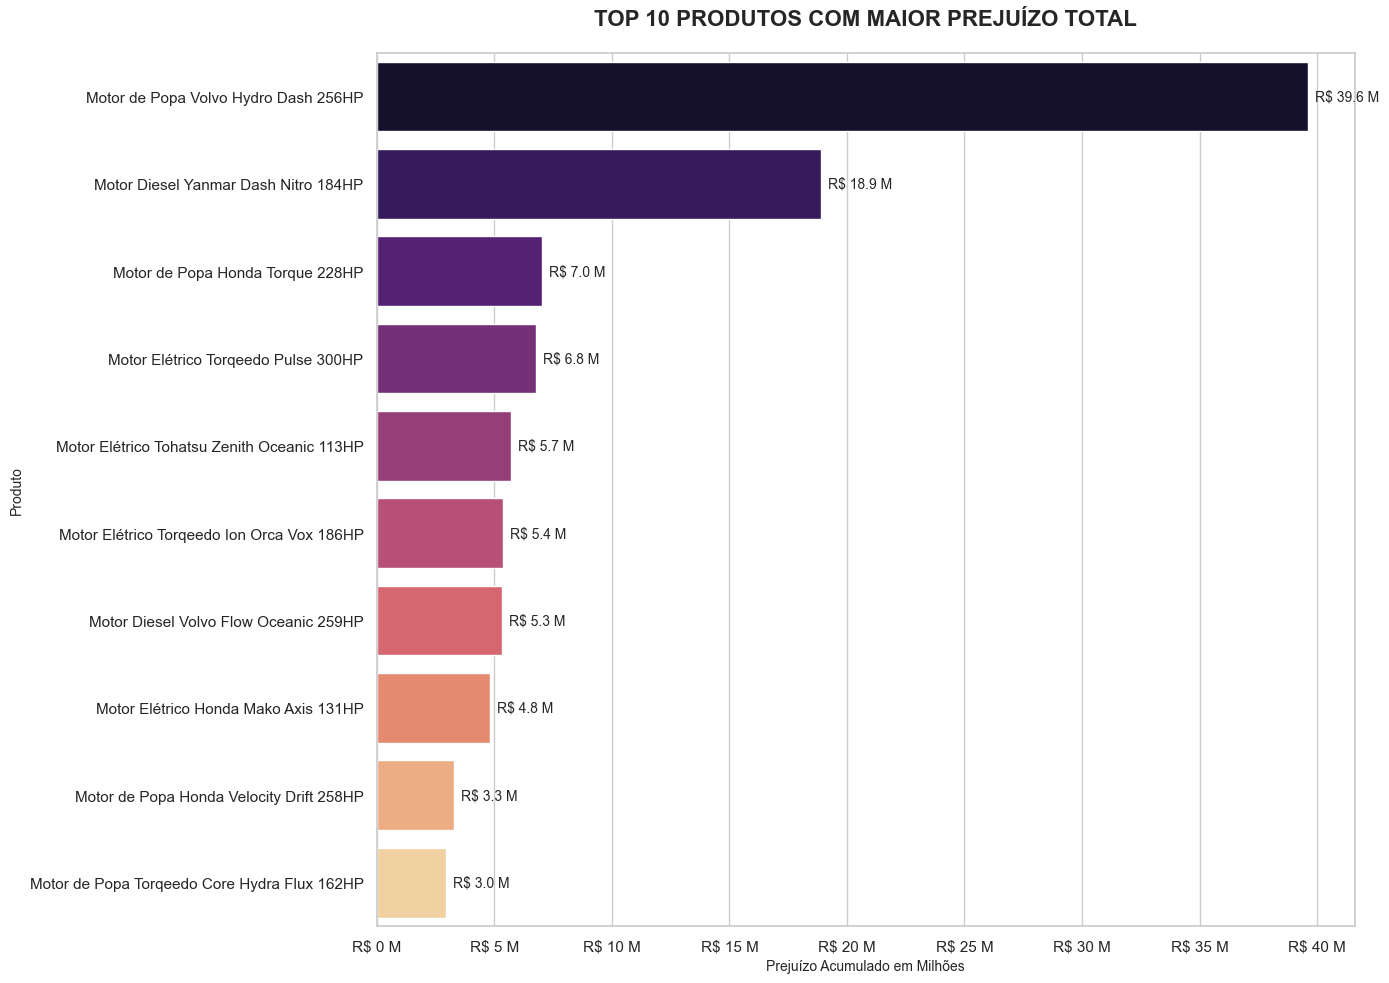

In [48]:
# GRÁFICO DE PREJUÍZO TOTAL POR PRODUTO 
top10_prejuizo = df_dados_agregados[df_dados_agregados['prejuizo_total'] > 0].nlargest(10, 'prejuizo_total')

plt.figure(figsize=(14, 10))
sns.set_theme(style="whitegrid")

# DEFININDO FORMATAÇÃO PARA EIXO X EM MILHÕES
def formatacao(x, pos):
    return f'R$ {x/1e6:.0f} M'

# CRUAÇÃO DO GRÁFICO DE BARRAS HORIZONTAIS 
grafico = sns.barplot( data=top10_prejuizo,
                       x='prejuizo_total',
                       y='product_name', 
                       palette='magma',
                       hue='product_name',
                       legend=False)
grafico.xaxis.set_major_formatter(FuncFormatter(formatacao))

for barra in grafico.containers:
    labels = [f'R$ {v.get_width()/1e6:.1f} M' for v in barra]
    grafico.bar_label(barra, labels=labels, padding=5, fontsize=10)

plt.title('TOP 10 PRODUTOS COM MAIOR PREJUÍZO TOTAL', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Prejuízo Acumulado em Milhões', fontsize=10)
plt.ylabel('Produto', fontsize=10)
plt.tight_layout()

# SALVANDO O GRÁFICO
plt.savefig(os.path.join(PATH_PLOTS, 'grafico_prejuizo.png'))
plt.show()

#### **4.3 - Análise Objetiva:**

In [50]:
# INDICANDO O PRODUTO COM MAIOR PREJUÍZO ABSOLUTO
produto_maior_prejuizo = df_dados_agregados.sort_values(by='prejuizo_total', ascending=False).iloc[0]
print(f"Produto com maior prejuízo absoluto: {produto_maior_prejuizo['product_name']} (ID: {produto_maior_prejuizo['id_product']})\nPrejuízo de R$ {produto_maior_prejuizo['prejuizo_total']/1e6:.2f} milhoes")
      
# INDICANDO O PRODUTO COM MAIOR PERCENTUAL DE PERDA
produto_maior_percentual_perda = df_dados_agregados[df_dados_agregados['percentual_perda'] > 0].sort_values(by='percentual_perda', ascending=False).iloc[0]
print(f"Produto com maior percentual de perda: {produto_maior_percentual_perda['product_name']} (ID: {produto_maior_percentual_perda['id_product']})\nPercentual de perda: {produto_maior_percentual_perda['percentual_perda']*100:.2f}%")

# VERIFICANDO SE O PRODUTO COM MAIOR PREJUÍZO ABSOLUTO É O MESMO QUE O PRODUTO COM MAIOR PERCENTUAL DE PERDA
print("É o mesmo produto com maior prejuízo e maior percentual de perda?", 
      "SIM" if produto_maior_prejuizo['id_product']==produto_maior_percentual_perda['id_product'] else "NÃO. Produtos diferentes")

Produto com maior prejuízo absoluto: Motor de Popa Volvo Hydro Dash 256HP (ID: 72)
Prejuízo de R$ 39.61 milhoes
Produto com maior percentual de perda: Motor de Popa Volvo Hydro Dash 256HP (ID: 72)
Percentual de perda: 62.82%
É o mesmo produto com maior prejuízo e maior percentual de perda? SIM
